In [1]:
!pip install pandas numpy torch sentence-transformers scikit-learn


In [4]:

import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')


In [3]:
  from tqdm.autonotebook import tqdm, trange


In [17]:
class ScientificPaperRetrieval:
    def __init__(self, model_name='all-MiniLM-L6-v2', use_gpu=True):
        """
        Initialize the Scientific Paper Retrieval System
        
        Args:
            model_name: Sentence transformer model name
            use_gpu: Whether to use GPU acceleration
        """
        # Check GPU availability
        if use_gpu and torch.cuda.is_available():
            self.device = 'cuda'
            print(f"Using GPU: {torch.cuda.get_device_name(0)}")
        else:
            self.device = 'cpu'
            print("Using CPU")
        
        # Load the sentence transformer model
        print(f"Loading model: {model_name}")
        self.model = SentenceTransformer(model_name, device=self.device)
        
        # Storage for papers and embeddings
        self.papers_df = None
        self.paper_embeddings = None
        self.paper_texts = []
        
    def load_papers(self, csv_file_path):
        """
        Load scientific papers from CSV file
        
        Args:
            csv_file_path: Path to CSV file with columns: title, abstract, sections
        """
        print("Loading scientific papers...")
        self.papers_df = pd.read_csv(csv_file_path)
        
        # Validate required columns
        required_columns = ['title', 'abstract', 'sections']
        missing_columns = [col for col in required_columns if col not in self.papers_df.columns]
        if missing_columns:
            raise ValueError(f"Missing required columns: {missing_columns}")
        
        # Combine title, abstract, and sections into single text for each paper
        self.paper_texts = []
        for idx, row in self.papers_df.iterrows():
            # Handle NaN values
            title = str(row['title']) if pd.notna(row['title']) else ""
            abstract = str(row['abstract']) if pd.notna(row['abstract']) else ""
            sections = str(row['sections']) if pd.notna(row['sections']) else ""
            
            # Combine all text
            combined_text = f"Title: {title}. Abstract: {abstract}. Content: {sections}"
            self.paper_texts.append(combined_text)
        
        print(f"Loaded {len(self.paper_texts)} scientific papers")
        return self.papers_df
        
    def create_paper_embeddings(self):
        """
        Create embeddings for all scientific papers
        """
        if not self.paper_texts:
            raise ValueError("No papers loaded. Call load_papers() first.")
        
        print("Creating embeddings for scientific papers...")
        print("This may take a few minutes depending on the number of papers...")
        
        # Create embeddings with progress tracking
        batch_size = 32  # Adjust based on GPU memory
        self.paper_embeddings = self.model.encode(
            self.paper_texts,
            batch_size=batch_size,
            show_progress_bar=True,
            convert_to_numpy=True
        )
        
        print(f"Created embeddings with shape: {self.paper_embeddings.shape}")
        
    def load_queries(self, csv_file_path, query_column='sentence'):
        """
        Load queries from CSV file
        
        Args:
            csv_file_path: Path to CSV file with queries
            query_column: Name of the column containing queries
        """
        print("Loading queries...")
        queries_df = pd.read_csv(csv_file_path)
        
        if query_column not in queries_df.columns:
            raise ValueError(f"Column '{query_column}' not found in queries file")
        
        # Get non-null queries
        queries = queries_df[query_column].dropna().tolist()
        print(f"Loaded {len(queries)} queries")
        
        return queries
    
    def search_similar_papers(self, query, top_k=10):
        """
        Find top-k most similar papers for a given query
        
        Args:
            query: Query string (can be multiple sentences)
            top_k: Number of top similar papers to return
            
        Returns:
            List of dictionaries with paper info and similarity scores
        """
        if self.paper_embeddings is None:
            raise ValueError("Paper embeddings not created. Call create_paper_embeddings() first.")
        
        # Create embedding for the query
        query_embedding = self.model.encode([query], convert_to_numpy=True)
        
        # Calculate cosine similarity
        similarities = cosine_similarity(query_embedding, self.paper_embeddings)[0]
        
        # Get top-k most similar papers
        top_indices = np.argsort(similarities)[::-1][:top_k]
        
        results = []
        for idx in top_indices:
            paper_idx = int(idx)
            similarity_score = float(similarities[idx])
            
            result = {
                'paper_id': paper_idx,
                'similarity_score': similarity_score,
                'title': self.papers_df.iloc[paper_idx]['title'],
                'abstract': self.papers_df.iloc[paper_idx]['abstract'],
                'sections': self.papers_df.iloc[paper_idx]['sections']
            }
            results.append(result)
        
        return results
    
    def batch_search(self, queries, top_k=10):
        """
        Process multiple queries and return results for each
        
        Args:
            queries: List of query strings
            top_k: Number of top similar papers per query
            
        Returns:
            Dictionary with query as key and results as value
        """
        all_results = {}
        
        print(f"Processing {len(queries)} queries...")
        for i, query in enumerate(queries):
            print(f"Processing query {i+1}/{len(queries)}")
            results = self.search_similar_papers(query, top_k)
            all_results[f"Query_{i+1}"] = {
                'query_text': query,
                'results': results
            }
        
        return all_results
    
    def save_results_with_labels(self, results, output_file):
        """
        Save search results to CSV file including relevance labels
        
        Args:
            results: Results from batch search with labels
            output_file: Output CSV file path
        """
        rows = []
        for query_key, query_data in results.items():
            query_text = query_data['query_text']
            relevance_label = query_data['relevance_label']
            for result in query_data['results']:
                rows.append({
                    'query_id': query_key,
                    'query_text': query_text,
                    'query_relevance_label': relevance_label,
                    'paper_id': result['paper_id'],
                    'similarity_score': result['similarity_score'],
                    'paper_title': result['title'],
                    'paper_abstract': result['abstract'][:500] + "..." if len(str(result['abstract'])) > 500 else result['abstract'],
                    'paper_sections': result['sections'][:500] + "..." if len(str(result['sections'])) > 500 else result['sections']
                })
        
        results_df = pd.DataFrame(rows)
        results_df.to_csv(output_file, index=False)
        print(f"Results saved to: {output_file}")
        return results_df


In [18]:
retrieval_system = ScientificPaperRetrieval(
    model_name='all-MiniLM-L6-v2',  
    use_gpu=True
)

Using GPU: GRID V100S-32Q
Loading model: all-MiniLM-L6-v2


In [19]:
papers_file = "extracted_data_full.csv"

In [20]:
papers_df = retrieval_system.load_papers(papers_file)
print(f"\nPapers DataFrame shape: {papers_df.shape}")
print("\nFirst few papers:")
papers_df.head()

Loading scientific papers...
Loaded 118 scientific papers

Papers DataFrame shape: (118, 5)

First few papers:


,title,authors,abstract,sections,references
0,Land use and land cover change detection and p...,Sonam Wang; Lamchin Munkhnasan; Woo-Kyun Lee,Rapid urbanization is changing landscapes ofte...,"Introduction: Global cities, which are the eng...",Urban and Peri-urban agriculture in developing...
1,Environmental & Socio-economic Studies,Tran Nguyen; Tuan,Land-use change is a human process aimed at tr...,"Introduction: According to the literature, lan...","Research and Application Project of EORC, JAXA..."
2,Land-use change and biodiversity: Challenges f...,Charles Davison; | Carsten Rahbek; Naia Moruet...,Land-use change is considered the greatest thr...,| INTRODUC TI ON: The IPBES 2019 global report...,Adapting the Edinburgh geoparser for historica...
3,Land Use/Land Cover Changes and Their Driving ...,Chenli Liu; Wenlong Li; Gaofeng Zhu; Huakun Zh...,As an important production base for livestock ...,Introduction: Land use/land cover (LULC) chang...,Exploring land use/land cover change and drive...
4,Application of Remote Sensing Tools to Assess ...,Dimitrios Paraforos; Anselme Muzirafuti; Josep...,Land use and land cover (LULC) change has beco...,Introduction: Land use and land cover (LULC) c...,"Remote Sensing of Land Use and Land Cover (, ,..."


In [21]:
retrieval_system.create_paper_embeddings()


Creating embeddings for scientific papers...
This may take a few minutes depending on the number of papers...


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Created embeddings with shape: (118, 384)


In [23]:

# Load labeled sentences and filter for relevant ones
labeled_sentences_df = pd.read_csv('annotated_corpus_for_dataverse.csv')

# Show all unique labels in your data
print(f"Unique labels in your data: {sorted(labeled_sentences_df['relevance_label'].unique())}")

# Filter for relevance_label 1 and 2 only
relevant_sentences_df = labeled_sentences_df[labeled_sentences_df['relevance_label'].isin([1, 2])]
relevant_sentences = relevant_sentences_df['text_segment'].tolist()

print(f"Total labeled sentences: {len(labeled_sentences_df)}")
print(f"Sentences with label 1: {len(labeled_sentences_df[labeled_sentences_df['relevance_label'] == 1])}")
print(f"Sentences with label 2: {len(labeled_sentences_df[labeled_sentences_df['relevance_label'] == 2])}")
print(f"Total relevant sentences (labels 1,2) to use as queries: {len(relevant_sentences)}")

# Show sample of your relevant sentences
print(f"\nSample relevant sentences:")
for i, sentence in enumerate(relevant_sentences[:3]):
    label = relevant_sentences_df.iloc[i]['relevance_label']
    print(f"Label {label}: {sentence[:100]}...")

# Use first 10 relevant sentences as queries
queries_to_process = relevant_sentences[:10]
queries_labels = relevant_sentences_df['relevance_label'].tolist()[:10]

print(f"\nProcessing first 10 relevant queries:")
for i, (query, label) in enumerate(zip(queries_to_process[:3], queries_labels[:3])):
    print(f"Query {i+1} (Label {label}): {query[:100]}...")


Unique labels in your data: [0, 1, 2]
Total labeled sentences: 803
Sentences with label 1: 166
Sentences with label 2: 67
Total relevant sentences (labels 1,2) to use as queries: 233

Sample relevant sentences:
Label 2: #text': 'After the droughts in the 1970s and 1980s, the observed loss of woody vegetation cover was ...
Label 1: #text': 'Pastoral production has often existed in some sort of symbiotic interaction with the [agric...
Label 2: #text': 'The forests of West and Central Africa probably originally covered a combined area of about...

Processing first 10 relevant queries:
Query 1 (Label 2): #text': 'After the droughts in the 1970s and 1980s, the observed loss of woody vegetation cover was ...
Query 2 (Label 1): #text': 'Pastoral production has often existed in some sort of symbiotic interaction with the [agric...
Query 3 (Label 2): #text': 'The forests of West and Central Africa probably originally covered a combined area of about...


In [24]:

# Process all 10 queries and get top 10 similar papers for each
print("\nStarting batch search...")
results = {}

print(f"Processing {len(queries_to_process)} relevant queries...")
for i, (query, label) in enumerate(zip(queries_to_process, queries_labels)):
    print(f"Processing query {i+1}/{len(queries_to_process)} (Label: {label})")
    search_results = retrieval_system.search_similar_papers(query, top_k=10)
    results[f"Query_{i+1}"] = {
        'query_text': query,
        'relevance_label': label,
        'results': search_results
    }

print(f"\nCompleted! Processed {len(results)} relevant queries")


Starting batch search...
Processing 10 relevant queries...
Processing query 1/10 (Label: 2)
Processing query 2/10 (Label: 1)
Processing query 3/10 (Label: 2)
Processing query 4/10 (Label: 1)
Processing query 5/10 (Label: 1)
Processing query 6/10 (Label: 2)
Processing query 7/10 (Label: 2)
Processing query 8/10 (Label: 2)
Processing query 9/10 (Label: 2)
Processing query 10/10 (Label: 1)

Completed! Processed 10 relevant queries


In [ ]:
first_query_key = list(results.keys())[0]
first_results = results[first_query_key]

print(f"\n{'='*80}")
print(f"EXAMPLE RESULTS FOR: {first_query_key}")
print(f"{'='*80}")
print(f"Query Text: {first_results['query_text'][:150]}...")
print(f"Query Relevance Label: {first_results['relevance_label']}")
print(f"\nTop 5 Most Similar Papers:")
print("-" * 80)

for i, result in enumerate(first_results['results'][:5]):
    print(f"\nRank {i+1}:")
    print(f"Similarity Score: {result['similarity_score']:.4f}")
    print(f"Paper ID: {result['paper_id']}")
    print(f"Title: {result['title']}")
    print(f"Abstract: {str(result['abstract'])[:200]}...")
    print("-" * 40)

# Show summary by relevance label
print(f"\n{'='*60}")
print("SUMMARY BY RELEVANCE LABEL")
print(f"{'='*60}")

label_1_queries = [k for k, v in results.items() if v['relevance_label'] == 1]
label_2_queries = [k for k, v in results.items() if v['relevance_label'] == 2]

print(f"Queries with Label 1 (High Relevance): {len(label_1_queries)}")
print(f"Queries with Label 2 (Medium Relevance): {len(label_2_queries)}")

# Show average similarity scores by label
if label_1_queries:
    avg_score_label_1 = np.mean([np.mean([r['similarity_score'] for r in results[q]['results']]) 
                                 for q in label_1_queries])
    print(f"Average similarity score for Label 1 queries: {avg_score_label_1:.4f}")

if label_2_queries:
    avg_score_label_2 = np.mean([np.mean([r['similarity_score'] for r in results[q]['results']]) 
                                 for q in label_2_queries])
    print(f"Average similarity score for Label 2 queries: {avg_score_label_2:.4f}")


Save Results to CSV with Labels


In [27]:

# Save all results to a CSV file for further analysis
output_file = "retrieval_results_with_labels.csv"
results_df = retrieval_system.save_results_with_labels(results, output_file)

# Display summary of saved results
print(f"\nResults Summary:")
print(f"Total query-paper pairs: {len(results_df)}")
print(f"Average similarity score: {results_df['similarity_score'].mean():.4f}")
print(f"Highest similarity score: {results_df['similarity_score'].max():.4f}")

# Summary by relevance label
label_summary = results_df.groupby('query_relevance_label').agg({
    'similarity_score': ['count', 'mean', 'std', 'max', 'min']
}).round(4)

print(f"\nSummary by Query Relevance Label:")
print(label_summary)

# Display first few rows of results
print("\nFirst few result rows:")
results_df[['query_id', 'query_relevance_label', 'similarity_score', 'paper_title']].head(10)


Results saved to: retrieval_results_with_labels.csv

Results Summary:
Total query-paper pairs: 100
Average similarity score: 0.4369
Highest similarity score: 0.6379

Summary by Query Relevance Label:
                      similarity_score                                
                                 count    mean     std     max     min
query_relevance_label                                                 
1                                   40  0.3829  0.0466  0.4922  0.3284
2                                   60  0.4729  0.0779  0.6379  0.3309

First few result rows:


,query_id,query_relevance_label,similarity_score,paper_title
0,Query_1,2,0.526976,"Vegetation Trends, Drought Severity and Land U..."
1,Query_1,2,0.526976,"Vegetation Trends, Drought Severity and Land U..."
2,Query_1,2,0.504402,Land Use Policy
3,Query_1,2,0.496543,ISPRS Journal of Photogrammetry and Remote Sen...
4,Query_1,2,0.495264,Past and Future Land Use/Land Cover Changes in...
5,Query_1,2,0.494897,Analysis of Land Use/Land Cover Change and Its...
6,Query_1,2,0.487665,Detecting and Analyzing Land Use and Land Cove...
7,Query_1,2,0.487665,Detecting and Analyzing Land Use and Land Cove...
8,Query_1,2,0.483254,Analysis and prediction of land cover changes ...
9,Query_1,2,0.480348,Effects of Long-Term Land Use and Land Cover C...


Analysis and Visualization by Relevance Labels


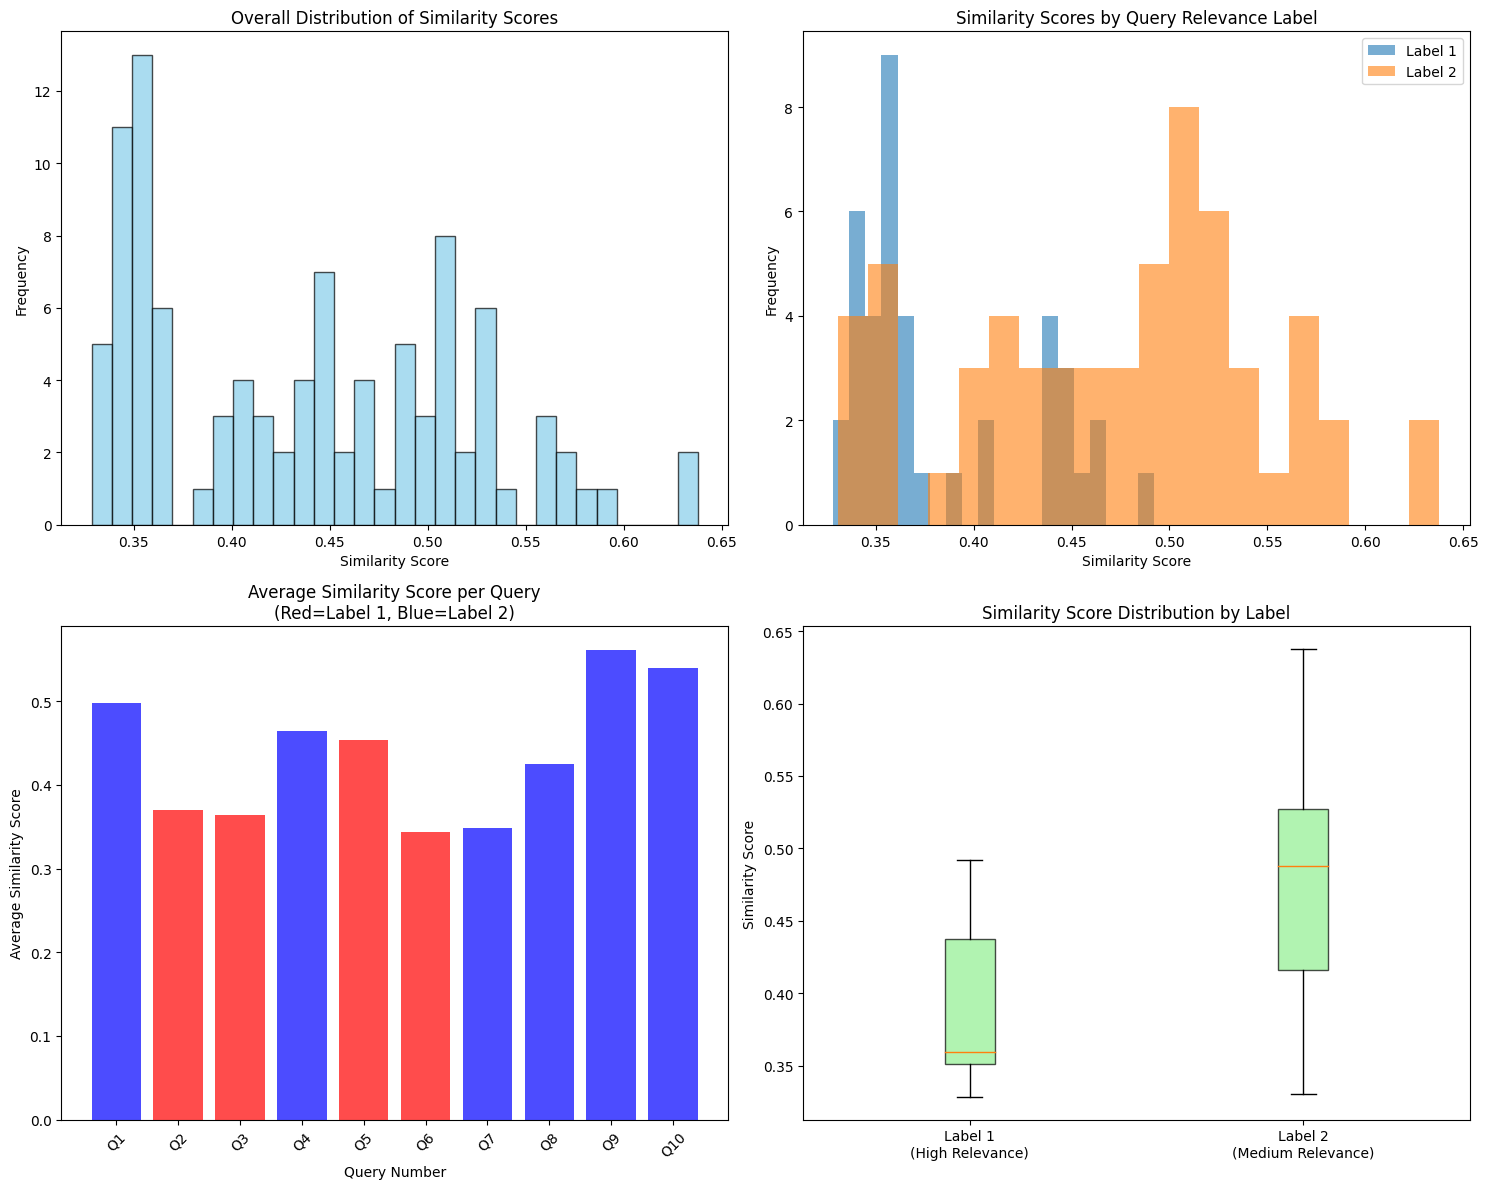


STATISTICAL ANALYSIS
T-test comparing Label 1 vs Label 2:
T-statistic: -6.5606
P-value: 0.0000
Significant difference: Yes (α=0.05)

Descriptive Statistics:
Label 1 - Mean: 0.3829, Std: 0.0466
Label 2 - Mean: 0.4729, Std: 0.0779

Top 3 Queries by Average Similarity Score:
                                similarity_score  \
query_id query_relevance_label                     
Query_8  2                              0.561637   
Query_9  2                              0.540132   
Query_1  2                              0.498399   

                                                                       query_text  
query_id query_relevance_label                                                     
Query_8  2                      [Forest] land was decreased nearly by half in ...  
Query_9  2                      About 26 and 31% of the total area of natural ...  
Query_1  2                      #text': 'After the droughts in the 1970s and 1...  


In [28]:

import matplotlib.pyplot as plt

# Create comprehensive visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Distribution of similarity scores
axes[0, 0].hist(results_df['similarity_score'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Overall Distribution of Similarity Scores')
axes[0, 0].set_xlabel('Similarity Score')
axes[0, 0].set_ylabel('Frequency')

# Plot 2: Similarity scores by relevance label
for label in sorted(results_df['query_relevance_label'].unique()):
    label_scores = results_df[results_df['query_relevance_label'] == label]['similarity_score']
    axes[0, 1].hist(label_scores, alpha=0.6, label=f'Label {label}', bins=20)
axes[0, 1].set_title('Similarity Scores by Query Relevance Label')
axes[0, 1].set_xlabel('Similarity Score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# Plot 3: Average similarity score per query
query_avg_scores = results_df.groupby('query_id')['similarity_score'].mean()
query_labels = [results[qid]['relevance_label'] for qid in query_avg_scores.index]
colors = ['red' if label == 1 else 'blue' for label in query_labels]

axes[1, 0].bar(range(len(query_avg_scores)), query_avg_scores.values, color=colors, alpha=0.7)
axes[1, 0].set_title('Average Similarity Score per Query\n(Red=Label 1, Blue=Label 2)')
axes[1, 0].set_xlabel('Query Number')
axes[1, 0].set_ylabel('Average Similarity Score')
axes[1, 0].set_xticks(range(len(query_avg_scores)))
axes[1, 0].set_xticklabels([f'Q{i+1}' for i in range(len(query_avg_scores))], rotation=45)

# Plot 4: Box plot comparison by label
label_1_scores = results_df[results_df['query_relevance_label'] == 1]['similarity_score']
label_2_scores = results_df[results_df['query_relevance_label'] == 2]['similarity_score']

box_data = [label_1_scores, label_2_scores]
box_labels = ['Label 1\n(High Relevance)', 'Label 2\n(Medium Relevance)']
axes[1, 1].boxplot(box_data, labels=box_labels, patch_artist=True,
                   boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[1, 1].set_title('Similarity Score Distribution by Label')
axes[1, 1].set_ylabel('Similarity Score')

plt.tight_layout()
plt.show()

# Statistical analysis
print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

from scipy import stats

if len(label_1_scores) > 0 and len(label_2_scores) > 0:
    # T-test to compare means between labels
    t_stat, p_value = stats.ttest_ind(label_1_scores, label_2_scores)
    print(f"T-test comparing Label 1 vs Label 2:")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'} (α=0.05)")
    
    print(f"\nDescriptive Statistics:")
    print(f"Label 1 - Mean: {label_1_scores.mean():.4f}, Std: {label_1_scores.std():.4f}")
    print(f"Label 2 - Mean: {label_2_scores.mean():.4f}, Std: {label_2_scores.std():.4f}")

# Top performing queries by label
print(f"\nTop 3 Queries by Average Similarity Score:")
query_performance = results_df.groupby(['query_id', 'query_relevance_label']).agg({
    'similarity_score': 'mean',
    'query_text': 'first'
}).sort_values('similarity_score', ascending=False)

print(query_performance.head(3))


In [30]:

def interactive_search(query_text, top_k=5):
    """
    Function to search for a custom query interactively
    """
    print(f"Searching for: '{query_text[:100]}...'")
    results = retrieval_system.search_similar_papers(query_text, top_k=top_k)
    
    print(f"\nTop {top_k} Similar Papers:")
    print("-" * 60)
    
    for i, result in enumerate(results):
        print(f"\nRank {i+1}:")
        print(f"Similarity Score: {result['similarity_score']:.4f}")
        print(f"Title: {result['title']}")
        print(f"Abstract: {str(result['abstract'])[:150]}...")
        print("-" * 40)
    
    return results
